In [1]:
import pandas as pd
import numpy as np
import glob
import os

In [2]:
DATA_PATH = "../data/raw"

files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print(f"Found {len(files)} CSV files:\n")

for file in files:
    print(os.path.basename(file))


Found 8 CSV files:

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


In [3]:
monday_file = [
    f for f in files
    if "Monday" in os.path.basename(f)
][0]

print(monday_file)

../data/raw/Monday-WorkingHours.pcap_ISCX.csv


In [4]:
df = pd.read_csv(monday_file)

print("Original shape:", df.shape)

Original shape: (529918, 79)


In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [7]:
df = df.replace([np.inf, -np.inf], np.nan)

In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 874


In [9]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Flow Bytes/s      437
Flow Packets/s    437
dtype: int64

In [10]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 529918
Rows after: 502983
Duplicates removed: 26935


In [11]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (502983, 78)
y shape: (502983,)


In [13]:
y.value_counts()

Label
BENIGN    502983
Name: count, dtype: int64

In [14]:
def clean_dataframe(df):
    # 1. Clean column names
    df.columns = df.columns.str.strip()

    # 2. Convert infinite values to NaN
    df = df.replace([np.inf, -np.inf], np.nan)

    # 3. Remove exact duplicate rows
    df = df.drop_duplicates()

    return df

In [15]:
def map_attack_label(label):
    label = str(label).strip()

    if label == "BENIGN":
        return "BENIGN"

    if label.startswith("DoS "):
        return "DoS"

    if label == "DDoS":
        return "DDoS"

    if label == "PortScan":
        return "PortScan"

    if label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"

    if "Web Attack" in label and "Brute Force" in label:
        return "Brute Force"

    if label == "Bot":
        return "Bot"

    if "Web Attack" in label:
        return "Web Attack"

    return "EXCLUDE"

In [16]:
test_labels = [
    "BENIGN",
    "DoS Hulk",
    "DoS GoldenEye",
    "DoS slowloris",
    "DoS Slowhttptest",
    "DDoS",
    "PortScan",
    "FTP-Patator",
    "SSH-Patator",
    "Bot",
    "Web Attack � Brute Force",
    "Web Attack � XSS",
    "Web Attack � Sql Injection",
    "Infiltration",
    "Heartbleed"
]

for label in test_labels:
    print(f"{label:40} → {map_attack_label(label)}")

BENIGN                                   → BENIGN
DoS Hulk                                 → DoS
DoS GoldenEye                            → DoS
DoS slowloris                            → DoS
DoS Slowhttptest                         → DoS
DDoS                                     → DDoS
PortScan                                 → PortScan
FTP-Patator                              → Brute Force
SSH-Patator                              → Brute Force
Bot                                      → Bot
Web Attack � Brute Force                 → Brute Force
Web Attack � XSS                         → Web Attack
Web Attack � Sql Injection               → Web Attack
Infiltration                             → EXCLUDE
Heartbleed                               → EXCLUDE


In [ ]:
def preprocess_file(file_path):
    """
    Load and perform basic preprocessing on one CICIDS2017 CSV file.
    """

    print(f"\nProcessing: {os.path.basename(file_path)}")


    df = pd.read_csv(file_path)

    print("Original shape:", df.shape)


    df.columns = df.columns.str.strip()

   
    df = df.replace([np.inf, -np.inf], np.nan)
    before_duplicates = len(df)
    df = df.drop_duplicates()
    duplicates_removed = before_duplicates - len(df)

    df["Label"] = df["Label"].apply(map_attack_label)

    before_exclusion = len(df)
    df = df[df["Label"] != "EXCLUDE"].copy()
    excluded = before_exclusion - len(df)

    print("Duplicates removed:", duplicates_removed)
    print("Rows excluded:", excluded)
    print("Final shape:", df.shape)

    return df

In [18]:
tuesday_file = [
    f for f in files
    if "Tuesday" in os.path.basename(f)
][0]

print(tuesday_file)

../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv


In [19]:
df_tuesday = preprocess_file(tuesday_file)


Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Original shape: (445909, 79)
Duplicates removed: 24065
Rows excluded: 0
Final shape: (421844, 79)


In [21]:
df_tuesday["Label"].value_counts()

Label
BENIGN         412692
Brute Force      9152
Name: count, dtype: int64

In [22]:
df_tuesday["Label"].value_counts(normalize=True) * 100

Label
BENIGN         97.830478
Brute Force     2.169522
Name: proportion, dtype: float64

In [23]:
"EXCLUDE" in df_tuesday["Label"].unique()

False

In [24]:
PROCESSED_PATH = "../data/processed"

os.makedirs(PROCESSED_PATH, exist_ok=True)

In [25]:
for file in files:

    processed_df = preprocess_file(file)

    filename = os.path.basename(file)
    output_file = os.path.join(
        PROCESSED_PATH,
        filename
    )

    processed_df.to_csv(
        output_file,
        index=False
    )

    print(f"Saved → {output_file}")


Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Original shape: (288602, 79)
Duplicates removed: 35630
Rows excluded: 36
Final shape: (252936, 79)
Saved → ../data/processed/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv

Processing: Monday-WorkingHours.pcap_ISCX.csv
Original shape: (529918, 79)
Duplicates removed: 26935
Rows excluded: 0
Final shape: (502983, 79)
Saved → ../data/processed/Monday-WorkingHours.pcap_ISCX.csv

Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Original shape: (191033, 79)
Duplicates removed: 6888
Rows excluded: 0
Final shape: (184145, 79)
Saved → ../data/processed/Friday-WorkingHours-Morning.pcap_ISCX.csv

Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Original shape: (286467, 79)
Duplicates removed: 72353
Rows excluded: 0
Final shape: (214114, 79)
Saved → ../data/processed/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Original sha

In [26]:
processed_files = glob.glob(
    os.path.join(PROCESSED_PATH, "*.csv")
)

print(f"Found {len(processed_files)} processed files")

Found 8 processed files


In [27]:
label_counts = {}

for file in processed_files:
    temp = pd.read_csv(file, usecols=["Label"])

    counts = temp["Label"].value_counts()

    for label, count in counts.items():
        label_counts[label] = label_counts.get(label, 0) + count

label_distribution = pd.Series(label_counts).sort_values(
    ascending=False
)

label_distribution

BENIGN         2148386
DoS             193748
DDoS            128016
PortScan         90819
Brute Force      10622
Bot               1953
Web Attack         673
dtype: int64

In [28]:
label_percentages = (
    label_distribution /
    label_distribution.sum()
) * 100

pd.DataFrame({
    "Count": label_distribution,
    "Percentage": label_percentages.round(2)
})

,Count,Percentage
BENIGN,2148386,83.46
DoS,193748,7.53
DDoS,128016,4.97
PortScan,90819,3.53
Brute Force,10622,0.41
Bot,1953,0.08
Web Attack,673,0.03


Matplotlib is building the font cache; this may take a moment.


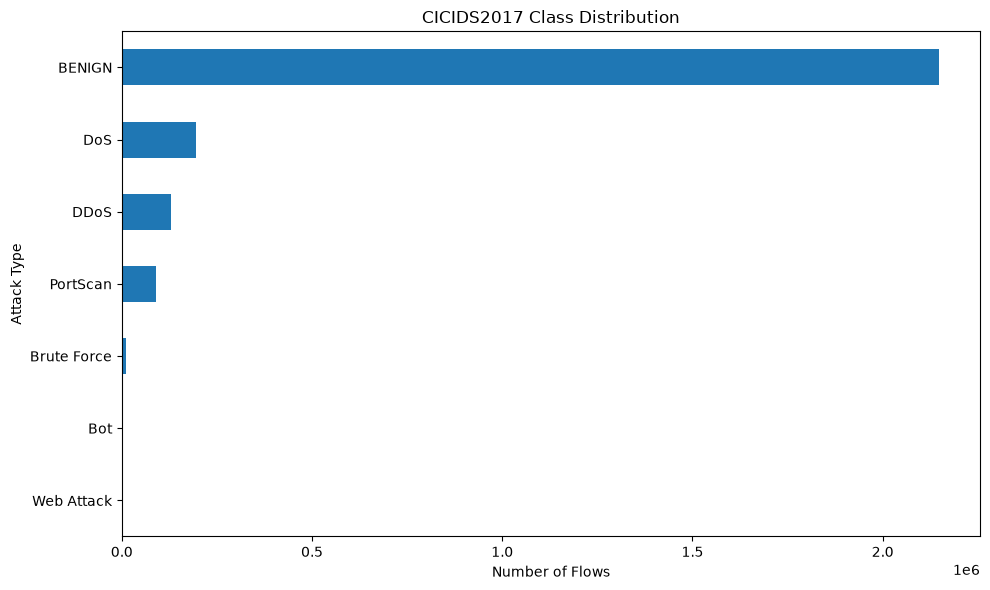

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

label_distribution.sort_values().plot(kind="barh")

plt.xlabel("Number of Flows")
plt.ylabel("Attack Type")
plt.title("CICIDS2017 Class Distribution")

plt.tight_layout()
plt.show()

In [30]:
pd.DataFrame({
    "Count": label_distribution,
    "Percentage": label_percentages.round(3)
})

,Count,Percentage
BENIGN,2148386,83.458
DoS,193748,7.526
DDoS,128016,4.973
PortScan,90819,3.528
Brute Force,10622,0.413
Bot,1953,0.076
Web Attack,673,0.026


In [31]:
for file in processed_files:
    print(os.path.basename(file))

print("Total files:", len(processed_files))

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Total files: 8


In [32]:
file_label_counts = {}

for file in processed_files:
    temp = pd.read_csv(file, usecols=["Label"])

    counts = temp["Label"].value_counts()

    file_label_counts[os.path.basename(file)] = counts

file_label_distribution = pd.DataFrame(file_label_counts).fillna(0).astype(int)

file_label_distribution

,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,Monday-WorkingHours.pcap_ISCX.csv,Friday-WorkingHours-Morning.pcap_ISCX.csv,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,Tuesday-WorkingHours.pcap_ISCX.csv,Wednesday-workingHours.pcap_ISCX.csv,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Label,,,,,,,,
BENIGN,252936,502983,182192,123295,95096,412692,417035,162157
Bot,0,0,1953,0,0,0,0,0
Brute Force,0,0,0,0,0,9152,0,1470
DDoS,0,0,0,0,128016,0,0,0
DoS,0,0,0,0,0,0,193748,0
PortScan,0,0,0,90819,0,0,0,0
Web Attack,0,0,0,0,0,0,0,673


In [33]:
SAMPLE_LIMITS = {
    "BENIGN": 150_000,
    "DoS": 150_000,
    "DDoS": 100_000,
    "PortScan": 90_819,
    "Brute Force": None,
    "Bot": None,
    "Web Attack": None
}

In [34]:
def sample_from_processed_files(
    processed_files,
    sample_limits,
    random_state=42
):
    """
    Sample a target number of rows from each class
    across multiple processed CICIDS2017 CSV files.

    Large classes are undersampled.
    Rare classes are kept completely.
    """

    # --------------------------------------------------
    # PASS 1: Count available samples for each class
    # --------------------------------------------------

    total_counts = {}

    print("Counting classes across files...\n")

    for file in processed_files:

        print(f"Reading: {os.path.basename(file)}")

        temp = pd.read_csv(
            file,
            usecols=["Label"]
        )

        counts = temp["Label"].value_counts()

        for label, count in counts.items():
            total_counts[label] = (
                total_counts.get(label, 0) + count
            )

    total_counts = pd.Series(total_counts)

    print("\nAvailable samples:")
    print(total_counts)

    # --------------------------------------------------
    # PASS 2: Sample from each file
    # --------------------------------------------------

    sampled_parts = []

    print("\nStarting sampling...\n")

    for file in processed_files:

        print(f"Processing: {os.path.basename(file)}")

        df = pd.read_csv(file)

        file_parts = []

        for label, limit in sample_limits.items():

            # Get rows belonging to this class
            class_df = df[df["Label"] == label]

            if len(class_df) == 0:
                continue

            # ------------------------------------------
            # Rare classes: keep everything
            # ------------------------------------------

            if limit is None:

                sampled_class = class_df

            # ------------------------------------------
            # Larger classes: proportional sampling
            # ------------------------------------------

            else:

                total_available = total_counts[label]

                desired = int(
                    limit *
                    len(class_df) /
                    total_available
                )

                # Never request more rows than exist
                desired = min(
                    desired,
                    len(class_df)
                )

                if desired == 0:
                    continue

                sampled_class = class_df.sample(
                    n=desired,
                    random_state=random_state
                )

            file_parts.append(sampled_class)

        # Combine sampled classes from this file

        if file_parts:

            file_sample = pd.concat(
                file_parts,
                ignore_index=True
            )

            sampled_parts.append(file_sample)

    # --------------------------------------------------
    # PASS 3: Combine everything
    # --------------------------------------------------

    print("\nCombining sampled data...")

    result = pd.concat(
        sampled_parts,
        ignore_index=True
    )

    # --------------------------------------------------
    # PASS 4: Shuffle
    # --------------------------------------------------

    print("Shuffling dataset...")

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    print("\nSampling complete!")

    return result

In [35]:
sampled_df = sample_from_processed_files(
    processed_files,
    SAMPLE_LIMITS
)

Counting classes across files...

Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: Monday-WorkingHours.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: Tuesday-WorkingHours.pcap_ISCX.csv
Reading: Wednesday-workingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Available samples:
BENIGN         2148386
Bot               1953
PortScan         90819
DDoS            128016
Brute Force      10622
DoS             193748
Web Attack         673
dtype: int64

Starting sampling...

Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: Monday-WorkingHours.pcap_ISCX.csv
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: Tu

In [36]:
print("Final shape:", sampled_df.shape)

Final shape: (504063, 79)


In [37]:
pd.DataFrame({
    "Count": sampled_df["Label"].value_counts(),
    "Percentage": (
        sampled_df["Label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(3)
    )
})

,Count,Percentage
Label,,
DoS,150000,29.758
BENIGN,149996,29.757
DDoS,100000,19.839
PortScan,90819,18.017
Brute Force,10622,2.107
Bot,1953,0.387
Web Attack,673,0.134


In [38]:
sampled_path = "../data/processed/model_dataset.csv"

sampled_df.to_csv(
    sampled_path,
    index=False
)

print("Saved successfully!")
print(sampled_path)

Saved successfully!
../data/processed/model_dataset.csv
